# 📊**BernoulliNB x MultinomialNB - Naive Bayes**

* O objetivo deste projeto é comparar os classificadores _Mutinomial Naive Bayes_ e _Bernoulli Naive Bayes_ em um problema de classificação de mensagens. O _MultinomialNB_ será aplicado a dados que representam a **frequência** de ocorrência das palavras, enquanto o _BernoulliNB_ será aplicado a dados **binários** que representam apenas a presença ou ausência dessas palavras. 

**OBS.:** A base de dados utilizada neste notebook é sintética, criada apenas por motivos didáticos.

In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score,
    confusion_matrix,
)

* As duas tabelas que serão utilizadas no treinamento dos modelos.

In [2]:
bernoulli = pd.read_csv('../data/base_bernoulli_nb_desafio.csv')
multinomial = pd.read_csv('../data/base_multinomial_nb_desafio.csv')

* Na tabela de _Bernoulli_ o valor "1" representa que aquele valor da variável foi encontrado no e-mail da observação correspondente, ou seja, na primeira observação, por exemplo, foram encontrados os termos: "promocao", "premio", "oferta" e "reuniao" em um email que foi classificado como _"Spam"_.

In [3]:
bernoulli.head(5)

,ID,Mensagem,Classe,promocao,desconto,gratis,premio,oferta,ganhe,urgente,reuniao,projeto,relatorio,equipe,cliente,prazo,agenda,documento,acesso,conta
0,1,promocao promocao promocao promocao premio ofe...,Spam,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0
1,2,promocao desconto desconto premio ganhe ganhe ...,Spam,1,1,0,1,0,1,1,0,0,0,0,1,0,0,0,1,0
2,3,desconto desconto premio premio relatorio equipe,Spam,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0
3,4,promocao promocao promocao desconto desconto d...,Spam,1,1,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0
4,5,promocao projeto relatorio conta,Spam,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1


* Por outro lado, a tabela Multinomial traz a quantidade de vezes que aquele termo apareceu no e-mail, ou seja, sua frequência.

In [4]:
multinomial.head(5)

,ID,Mensagem,Classe,promocao,desconto,gratis,premio,oferta,ganhe,urgente,reuniao,projeto,relatorio,equipe,cliente,prazo,agenda,documento,acesso,conta
0,1,promocao promocao promocao promocao premio ofe...,Spam,4,0,0,1,3,0,0,2,0,0,0,0,0,0,0,0,0
1,2,promocao desconto desconto premio ganhe ganhe ...,Spam,1,2,0,1,0,2,1,0,0,0,0,1,0,0,0,2,0
2,3,desconto desconto premio premio relatorio equipe,Spam,0,2,0,2,0,0,0,0,0,1,1,0,0,0,0,0,0
3,4,promocao promocao promocao desconto desconto d...,Spam,3,4,0,1,0,0,0,0,1,2,0,0,1,0,0,0,0
4,5,promocao projeto relatorio conta,Spam,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1


In [5]:
#criação de um dataframe comparando as primeiras observações de cada tabela
comparacao = pd.DataFrame({
    "Multinomial": multinomial.iloc[0],
    "Bernoulli": bernoulli.iloc[0]
})

comparacao

,Multinomial,Bernoulli
ID,1,1
Mensagem,promocao promocao promocao promocao premio ofe...,promocao promocao promocao promocao premio ofe...
Classe,Spam,Spam
promocao,4,1
desconto,0,0
gratis,0,0
premio,1,1
oferta,3,1
ganhe,0,0
urgente,0,0


In [23]:
#distribuição das classes 
bernoulli['Classe'].value_counts()

Classe
Spam        150
Trabalho    150
Name: count, dtype: int64

In [7]:
multinomial['Classe'].value_counts()

Classe
Spam        150
Trabalho    150
Name: count, dtype: int64

### **Frequência média das palavras**

In [8]:
multinomial.groupby('Classe').mean(numeric_only=True)

,ID,promocao,desconto,gratis,premio,oferta,ganhe,urgente,reuniao,projeto,relatorio,equipe,cliente,prazo,agenda,documento,acesso,conta
Classe,,,,,,,,,,,,,,,,,,
Spam,75.5,1.193333,1.213333,0.993333,0.380000,1.206667,0.873333,0.393333,0.240000,0.173333,0.14,0.126667,0.266667,0.213333,0.166667,0.266667,0.286667,0.286667
Trabalho,225.5,0.180000,0.313333,0.160000,0.153333,0.266667,0.166667,0.200000,0.973333,0.966667,0.94,0.813333,0.866667,0.853333,0.580000,0.420000,0.286667,0.226667


In [9]:
bernoulli.groupby('Classe').mean(numeric_only=True)

,ID,promocao,desconto,gratis,premio,oferta,ganhe,urgente,reuniao,projeto,relatorio,equipe,cliente,prazo,agenda,documento,acesso,conta
Classe,,,,,,,,,,,,,,,,,,
Spam,75.5,0.606667,0.526667,0.44,0.313333,0.56,0.353333,0.300000,0.193333,0.160000,0.113333,0.106667,0.206667,0.173333,0.120000,0.213333,0.226667,0.233333
Trabalho,225.5,0.160000,0.253333,0.12,0.133333,0.20,0.126667,0.166667,0.620000,0.553333,0.613333,0.486667,0.520000,0.540000,0.446667,0.366667,0.240000,0.200000


* Na tabela de Bernoulli os valores das médias de cada variável podem ser interpretados como a frequência em que aquela palavra apareceu no e-mail de _spam_ ou no e-mail de trabalho, por exemplo:
  * Em e-mails classificados como _spam_ em 60% deles apareceu a palavra "promoção", por outro lado, essa mesma palavra apareceu em somente 16% dos e-mails classificados como sendo de trabalho.

### **Preparação de X e y**

In [24]:
X_mult = multinomial.drop(columns=['ID', 'Mensagem', 'Classe'])
y_mult = multinomial['Classe']

X_bern = bernoulli.drop(columns=['ID', 'Mensagem', 'Classe'])

* Ambas as tabelas possuem os mesmos registros e o objetivo deste notebook é comparar os resultados de um modelo com o outro, por esse motivo as mesmas observações que forem usadas para treinar o _MultinomialNB_ serão usadas para treinar o _BernoulliNB_ também.

In [25]:
X_mult_train, X_mult_test, y_train, y_test = train_test_split(
    X_mult,
    y_mult, 
    test_size=0.2,
    random_state=42, 
    stratify=y_mult
)

In [26]:
#utilizando os mesmos índices para Bernoulli
X_bern_train = X_bern.loc[X_mult_train.index]
X_bern_test = X_bern.loc[X_mult_test.index]

### **Treinamento - MultinominalNB**

In [27]:
mult_model = MultinomialNB()
mult_model.fit(X_mult_train, y_train)
y_mult_pred = mult_model.predict(X_mult_test)

### **Avaliação - MultinomialNB**

In [30]:
print('Accuracy: ', accuracy_score(y_test, y_mult_pred))

#pos_label é utilizada aqui para tratar a classe "Spam" como sendo positiva e as métricas a seguir levam isso em consideração
print('Precision: ', precision_score(y_test, y_mult_pred, pos_label='Spam'))

print('Recall: ', recall_score(y_test, y_mult_pred, pos_label='Spam'))

print('F1-score: ', f1_score(y_test, y_mult_pred, pos_label='Spam'))

Accuracy:  0.9333333333333333
Precision:  0.9333333333333333
Recall:  0.9333333333333333
F1-score:  0.9333333333333333


### **Matriz de Confusão - Multinomial**

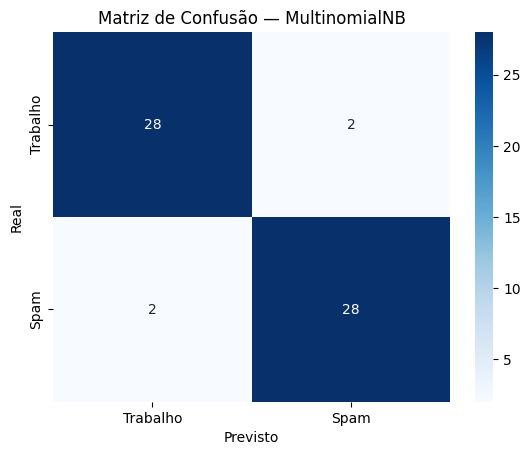

In [31]:
cm_mult = confusion_matrix(
    y_test,
    y_mult_pred,
    labels=["Trabalho", "Spam"]
)

sns.heatmap(
    cm_mult,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Trabalho", "Spam"],
    yticklabels=["Trabalho", "Spam"]
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão — MultinomialNB")

plt.show()

* Dos valores 60 valores de teste, 56 foram classificados corretamente pelo modelo Multinomial com base no conjunto de treinamento.

### **Treinamento - BernoulliNB**

In [32]:
bern_model = BernoulliNB()
bern_model.fit(X_bern_train, y_train)
y_bern_pred = bern_model.predict(X_bern_test)

### **Avaliação - BernoulliNB**

In [33]:
print("Accuracy:", accuracy_score(y_test, y_bern_pred))

print("Precision:", precision_score(y_test, y_bern_pred, pos_label="Spam"))

print("Recall:", recall_score(y_test, y_bern_pred, pos_label="Spam"))

print("F1-score:", f1_score(y_test, y_bern_pred, pos_label="Spam"))

Accuracy: 0.9
Precision: 0.9
Recall: 0.9
F1-score: 0.9


* Com base nas métricas, o modelo _BernoulliNB_ teve um desempenho levemente inferior ao _MultinomialNB_

### **Matriz de Confusão - Bernoulli**

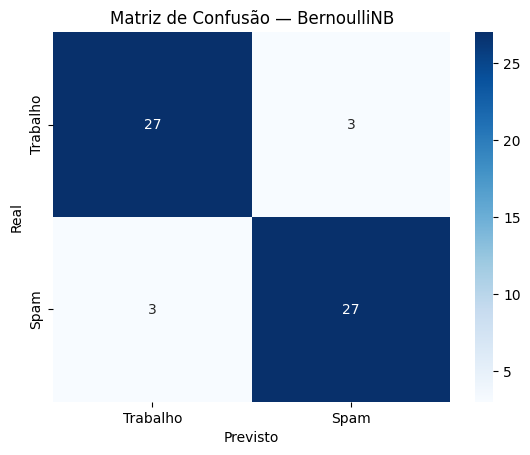

In [35]:
cm_mult = confusion_matrix(
    y_test,
    y_bern_pred,
    labels=["Trabalho", "Spam"]
)

sns.heatmap(
    cm_mult,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Trabalho", "Spam"],
    yticklabels=["Trabalho", "Spam"]
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão — BernoulliNB")

plt.show()

* Um comparativo entre os dois modelos.

In [34]:
resultados = pd.DataFrame({
    "Modelo": [
        "MultinomialNB",
        "BernoulliNB"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_mult_pred),
        accuracy_score(y_test, y_bern_pred)
    ],

    "Precision": [
        precision_score(
            y_test,
            y_bern_pred,
            pos_label="Spam"
        ),
        precision_score(
            y_test,
            y_bern_pred,
            pos_label="Spam"
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            y_mult_pred,
            pos_label="Spam"
        ),
        recall_score(
            y_test,
            y_bern_pred,
            pos_label="Spam"
        )
    ],

    "F1-score": [
        f1_score(
            y_test,
            y_mult_pred,
            pos_label="Spam"
        ),
        f1_score(
            y_test,
            y_bern_pred,
            pos_label="Spam"
        )
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,MultinomialNB,0.933333,0.9,0.933333,0.933333
1,BernoulliNB,0.900000,0.9,0.900000,0.900000


### **Comparativos**

* Por fim, vou criar um dataframe para analisarmos onde o modelo errou a previsão.

In [21]:
comparacao = pd.DataFrame({
    "Real": y_test,
    "Multinomial": y_mult_pred,
    "Bernoulli": y_bern_pred
})

comparacao

,Real,Multinomial,Bernoulli
71,Spam,Spam,Spam
41,Spam,Spam,Spam
88,Spam,Spam,Spam
124,Spam,Spam,Spam
1,Spam,Spam,Spam
91,Spam,Spam,Spam
254,Trabalho,Trabalho,Trabalho
140,Spam,Spam,Spam
177,Trabalho,Trabalho,Trabalho
48,Spam,Spam,Spam


* Há três situações nas quais eles podem ter errado e elas estão ilustradas logo abaixo:

In [38]:
# Ambos os modelos erraram a previsão
comparacao[
    (comparacao["Multinomial"] != comparacao["Real"]) &
    (comparacao["Bernoulli"] != comparacao ["Real"])
]

,Real,Multinomial,Bernoulli
99,Spam,Trabalho,Trabalho
74,Spam,Trabalho,Trabalho
152,Trabalho,Spam,Spam
290,Trabalho,Spam,Spam


In [41]:
# apenas o modelo Bernoulli errou a previsão
comparacao[
    (comparacao["Multinomial"] == comparacao["Real"]) &
    (comparacao["Bernoulli"] != comparacao["Real"])
]

,Real,Multinomial,Bernoulli
116,Spam,Spam,Trabalho
270,Trabalho,Trabalho,Spam


In [ ]:
# somente o modelo MultinomialNB errou a previsão
comparacao[
    (comparacao["Bernoulli"] == comparacao["Real"]) &
    (comparacao["Multinomial"] != comparacao["Real"])
]

,Real,Multinomial,Bernoulli


* Como é possível notar, ou os dois modelos erraram ao mesmo tempo, ou apenas o _BernoulliNB_ errou.

### **Conclusão**

Após organização das variáveis, treinamento dos modelos e análise das métricas é possível concluir que: nesse conjunto de dados, a representação baseada em frequência das palavras apresentou desempenho superior à representação baseada apenas na presença ou ausência das palavras.